In [1]:
import pandas as pd

df = pd.read_csv("../data/esol.csv")
df.head()import pandas as pd
import numpy as np

In [2]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
df = pd.read_csv(url)
df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [3]:
df.shape

(1128, 10)

In [4]:
df.columns

Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='str')

In [5]:
df.isnull().sum()

Compound ID                                        0
ESOL predicted log solubility in mols per litre    0
Minimum Degree                                     0
Molecular Weight                                   0
Number of H-Bond Donors                            0
Number of Rings                                    0
Number of Rotatable Bonds                          0
Polar Surface Area                                 0
measured log solubility in mols per litre          0
smiles                                             0
dtype: int64

In [6]:
df.describe()

,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,-2.988192,1.058511,203.937074,0.701241,1.390957,2.177305,34.872881,-3.050102
std,1.683220,0.238560,102.738077,1.089727,1.318286,2.640974,35.383593,2.096441
min,-9.702000,0.000000,16.043000,0.000000,0.000000,0.000000,0.000000,-11.600000
25%,-3.948250,1.000000,121.183000,0.000000,0.000000,0.000000,0.000000,-4.317500
50%,-2.870000,1.000000,182.179000,0.000000,1.000000,1.000000,26.300000,-2.860000
75%,-1.843750,1.000000,270.372000,1.000000,2.000000,3.000000,55.440000,-1.600000
max,1.091000,2.000000,780.949000,11.000000,8.000000,23.000000,268.680000,1.580000


In [7]:
df.to_csv("../data/esol.csv", index=False)

In [1]:
import pandas as pd

df = pd.read_csv("../data/esol.csv")
df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [2]:
from rdkit import Chem

df.columns

Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='str')

In [3]:
smiles_example = df["smiles"].iloc[0]
smiles_example

'OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O '

In [4]:
mol = Chem.MolFromSmiles(smiles_example)
mol

In [5]:
from rdkit.Chem import Descriptors

mw = Descriptors.MolWt(mol)
logp = Descriptors.MolLogP(mol)
tpsa = Descriptors.TPSA(mol)
hbd = Descriptors.NumHDonors(mol)
hba = Descriptors.NumHAcceptors(mol)
rot = Descriptors.NumRotatableBonds(mol)

mw, logp, tpsa, hbd, hba, rot

(457.4320000000001, -3.1080199999999985, 202.31999999999996, 7, 12, 7)

In [6]:
def compute_descriptors(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol),
    }

compute_descriptors(smiles_example)

{'MW': 457.4320000000001,
 'LogP': -3.1080199999999985,
 'TPSA': 202.31999999999996,
 'HBD': 7,
 'HBA': 12,
 'RotatableBonds': 7}

In [7]:
desc_list = df["smiles"].apply(compute_descriptors)
desc_df = pd.DataFrame([d for d in desc_list if d is not None])
desc_df.head()

,MW,LogP,TPSA,HBD,HBA,RotatableBonds
0,457.432,-3.10802,202.32,7,12,7
1,201.225,2.84032,42.24,1,2,2
2,152.237,2.87800,17.07,0,1,4
3,278.354,6.29940,0.00,0,0,0
4,84.143,1.74810,0.00,0,1,0


In [8]:
df_descriptors = pd.concat([df.reset_index(drop=True), desc_df.reset_index(drop=True)], axis=1)
df_descriptors.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,MW,LogP,TPSA,HBD,HBA,RotatableBonds
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,457.432,-3.10802,202.32,7,12,7
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2,201.225,2.84032,42.24,1,2,2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O),152.237,2.87800,17.07,0,1,4
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,278.354,6.29940,0.00,0,0,0
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1,84.143,1.74810,0.00,0,1,0


In [9]:
df_descriptors.to_csv("../data/esol_descriptors.csv", index=False)

In [10]:
df_descriptors.shape
df_descriptors.isnull().sum()

Compound ID                                        0
ESOL predicted log solubility in mols per litre    0
Minimum Degree                                     0
Molecular Weight                                   0
Number of H-Bond Donors                            0
Number of Rings                                    0
Number of Rotatable Bonds                          0
Polar Surface Area                                 0
measured log solubility in mols per litre          0
smiles                                             0
MW                                                 0
LogP                                               0
TPSA                                               0
HBD                                                0
HBA                                                0
RotatableBonds                                     0
dtype: int64

In [11]:
df_descriptors[["MW", "LogP", "TPSA", "HBD", "HBA", "RotatableBonds"]].describe()

,MW,LogP,TPSA,HBD,HBA,RotatableBonds
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,203.937074,2.447520,34.872881,0.701241,2.069149,2.177305
std,102.738077,1.852875,35.383593,1.089727,2.109388,2.640974
min,16.043000,-7.571400,0.000000,0.000000,0.000000,0.000000
25%,121.183000,1.414900,0.000000,0.000000,0.000000,0.000000
50%,182.179000,2.339000,26.300000,0.000000,2.000000,1.000000
75%,270.372000,3.402200,55.440000,1.000000,3.000000,3.000000
max,780.949000,10.388600,268.680000,11.000000,16.000000,23.000000


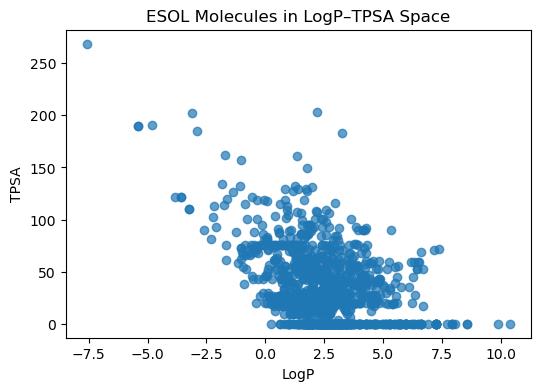

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df_descriptors["LogP"], df_descriptors["TPSA"], alpha=0.7)
plt.xlabel("LogP")
plt.ylabel("TPSA")
plt.title("ESOL Molecules in LogP–TPSA Space")
plt.show()

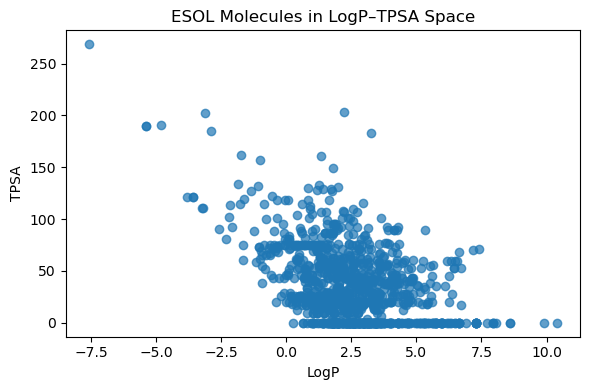

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df_descriptors["LogP"], df_descriptors["TPSA"], alpha=0.7)
plt.xlabel("LogP")
plt.ylabel("TPSA")
plt.title("ESOL Molecules in LogP–TPSA Space")
plt.tight_layout()
plt.savefig("../figures/esol_logp_tpsa_scatter.png", dpi=300, bbox_inches="tight")
plt.show()